In [1]:
%load_ext autoreload
%autoreload 2

import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import gsw
# import regionate
import cartopy.crs as ccrs
# import CM4Xutils #needed to run pip install nc-time-axis
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import cartopy.feature as cfeature
import warnings
# from numpy import RankWarning
import cmocean as cm
warnings.filterwarnings('ignore')
import xesmf as xe
from meridional_streamfunction import * 

In [2]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='compute',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=8)

client = Client(cluster)
client

2026-04-08 11:18:17,638 - distributed.diskutils - ERROR - Failed to remove '/tmp/dask-scratch-space/worker-j_ea3d18' (failed in <built-in function open>): [Errno 13] Permission denied: '/tmp/dask-scratch-space/worker-j_ea3d18'
2026-04-08 11:18:17,640 - distributed.diskutils - ERROR - Failed to remove '/tmp/dask-scratch-space/worker-78pt76dk' (failed in <built-in function open>): [Errno 13] Permission denied: '/tmp/dask-scratch-space/worker-78pt76dk'
2026-04-08 11:18:17,640 - distributed.diskutils - ERROR - Failed to remove '/tmp/dask-scratch-space/worker-7ykd8qns' (failed in <built-in function open>): [Errno 13] Permission denied: '/tmp/dask-scratch-space/worker-7ykd8qns'
2026-04-08 11:18:17,641 - distributed.diskutils - ERROR - Failed to remove '/tmp/dask-scratch-space/worker-v3w4zthh' (failed in <built-in function open>): [Errno 13] Permission denied: '/tmp/dask-scratch-space/worker-v3w4zthh'


#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/bin/python -m distributed.cli.dask_worker tcp://172.16.3.94:37203 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.94:37203,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [3]:
def get_latitude_average(ds, lats, grid=None):
    """
    Calculates time-mean meridional isopycnal overturning streamfunction using
    meridional convergence, which accounts for the tripolar grid .
    """
    # ====================================================
    # 0. take time average (to remove isopycnal heave) and setup grid
    # ====================================================
    ds_mean = ds.fillna(0.0)
    if grid is None:
        grid = CM4Xutils.ds_to_grid(ds_mean, Zprefix="sigma2")
        
    ds_list = []
    # Load native v-grid metrics
    wet_v = ds_mean["wet_v"].fillna(0.0)
    dxCv = ds_mean["dxCv"].fillna(0.0)
    
    vars_on_yh = ["tauy"]
    
    for var in vars_on_yh: 
        ds_var_list = []
        # Interpolate depth to cell faces (yq)
        ds_var_yq = grid.interp(ds[var], axis="Y", boundary="fill")
    
        
        for l in lats:
            # a. Calculate the convergence across a latitude mask 
            #(-div_v, since grid.diff calculate north_point - south_point but we need  south_point - north_point
            mask_south_yh = ds_mean["geolat"] <= l
            
            # b. Find the yq points that outline the mask
            mask_float = mask_south_yh.astype(float)
            boundary_mask_yq = grid.diff(mask_float, axis="Y", boundary="fill") < 0 #grid.diff calculate north_point - south_point
            
            # c. pull out the valid ocean points
            valid_bnd = boundary_mask_yq & (wet_v == 1)
            
            # d. Extract depth and width exactly along the wet boundary
            ds_var_yq_bnd = ds_var_yq.where(valid_bnd)
            dx_bnd = dxCv.where(valid_bnd)
            
            # e. Length-weighted boundary average
            z_weighted = (ds_var_yq_bnd * dx_bnd).sum(dim=["xh", "yq"], skipna=True)
            length_tot = dx_bnd.sum(dim=["xh", "yq"], skipna=True)
            
            term_var = z_weighted / length_tot.where(length_tot > 0)
            ds_var_list.append(term_var)
            
        # ====================================================
        # 4. Integrate transport and construct the psi dataset. 
        # ====================================================
        lat_dim = xr.DataArray(lats, dims='lat', name='lat')
        ds_var_lat = xr.concat(ds_var_list, dim=lat_dim).rename(var)
        ds_list += [ds_var_lat]

    return xr.merge(ds_list)


In [4]:
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/budget_sigma2_v1.2.0/" + x

datafiles = glob.glob(datadir("CM4Xp125*"))[20:]
datafiles = sorted(datafiles)
get_transports = lambda ds: ds[["tauy", "taux", "thkcello", "sigma2_i", "zos", "wet_v"]]


In [5]:
import cmip_basins.cmip6 as cmip6_basins
from cmip_basins.basins import generate_basin_codes


In [10]:
ds = xr.open_mfdataset(
    datafiles[0:2],
    data_vars="minimal",
    coords="minimal",
    compat="override",
    parallel=True,
    # preprocess = get_transports, 
    engine="zarr")#.chunk({"time":60})
ds

<xarray.Dataset> Size: 362GB
Dimensions:                         (exp: 2, time: 120, sigma2_l: 76, yh: 224,
                                     xh: 240, time_bounds: 122, xq: 241,
                                     yq: 225, sigma2_i: 77)
Coordinates: (12/30)
  * exp                             (exp) object 16B 'forced' 'control'
  * time                            (time) object 960B 1850-01-16 12:00:00 .....
  * sigma2_l                        (sigma2_l) float64 608B -503.0 ... 539.0
  * yh                              (yh) int64 2kB 0 1 2 3 4 ... 220 221 222 223
  * xh                              (xh) int64 2kB 0 1 2 3 4 ... 236 237 238 239
  * time_bounds                     (time_bounds) object 976B 1850-01-01 00:0...
    ...                              ...
    rho2_l                          (sigma2_l) float64 608B dask.array<chunksize=(76,), meta=np.ndarray>
    time_bounds_since_init          (time_bounds) object 976B dask.array<chunksize=(1,), meta=np.ndarray>
    time_since_init                 (time) object 960B dask.array<chunksize=(1,), meta=np.ndarray>
    wet                             (yh, xh) float64 430kB dask.array<chunksize=(224, 240), meta=np.ndarray>
    wet_u                           (yh, xq) float64 432kB dask.array<chunksize=(224, 241), meta=np.ndarray>
    wet_v                           (yq, xh) float64 432kB dask.array<chunksize=(225, 240), meta=np.ndarray>
Data variables: (12/54)
    boundary_forcing_h_tendency     (exp, time, sigma2_l, yh, xh) float64 8GB dask.array<chunksize=(2, 1, 76, 224, 240), meta=np.ndarray>
    boundary_forcing_heat_tendency  (exp, time, sigma2_l, yh, xh) float64 8GB dask.array<chunksize=(2, 1, 76, 224, 240), meta=np.ndarray>
    boundary_forcing_salt_tendency  (exp, time, sigma2_l, yh, xh) float64 8GB dask.array<chunksize=(2, 1, 76, 224, 240), meta=np.ndarray>
    dhdt                            (exp, time, sigma2_l, yh, xh) float64 8GB dask.array<chunksize=(2, 1, 76, 224, 240), meta=np.ndarray>
    dynamics_h_tendency             (exp, time, sigma2_l, yh, xh) float64 8GB dask.array<chunksize=(2, 1, 76, 224, 240), meta=np.ndarray>
    ePBL_h_ML                       (exp, time, yh, xh) float64 103MB dask.array<chunksize=(2, 1, 224, 240), meta=np.ndarray>
    ...                              ...
    umo                             (exp, time, sigma2_l, yh, xq) float64 8GB dask.array<chunksize=(2, 1, 76, 224, 241), meta=np.ndarray>
    vert_remap_h_tendency           (exp, time, sigma2_l, yh, xh) float64 8GB dask.array<chunksize=(2, 1, 76, 224, 240), meta=np.ndarray>
    vmo                             (exp, time, sigma2_l, yq, xh) float64 8GB dask.array<chunksize=(2, 1, 76, 225, 240), meta=np.ndarray>
    vprec                           (exp, time, sigma2_l, yh, xh) float64 8GB dask.array<chunksize=(2, 1, 76, 224, 240), meta=np.ndarray>
    wfo                             (exp, time, sigma2_l, yh, xh) float64 8GB dask.array<chunksize=(2, 1, 76, 224, 240), meta=np.ndarray>
    zos                             (exp, time, yh, xh) float64 103MB dask.array<chunksize=(2, 1, 224, 240), meta=np.ndarray>
Attributes: (12/13)
    filename:            ocean_monthly_z_d2.185001-185412.boundary_forcing_he...
    title:               CM4_historical_c192_OM4p125
    grid_type:           regular
    grid_tile:           N/A
    associated_files:    areacello: 18500101.D2ocean_static.nc
    history:             Fri Jun  9 01:32:07 2023: ncatted -O -a associated_f...
    ...                  ...
    external_variables:  volcello
    model:               CM4Xp125
    description:         The CM4Xp125 experimental design following Griffies ...
    provenance:          Diagnostics have been conservatively remapped into m...
    version:             v1.2.0
    version_notes:       Between v1.1.0 and v1.2.0, CM4Xutils has been upgrad...

In [ ]:
ds

In [21]:
ds = xr.open_mfdataset(
    datafiles,
    data_vars="minimal",
    coords="minimal",
    compat="override",
    parallel=True,
    preprocess = get_transports, 
    engine="zarr").chunk({"time":60})
codes = generate_basin_codes(ds, lon="geolon", lat="geolat", persian=True, style="cmip6")

so_ind_pac_mask = codes.isin([1, 3, 5, 10, 11])
so_ind_pac_mask = so_ind_pac_mask.where(so_ind_pac_mask > 0.0)

grid = CM4Xutils.ds_to_grid(ds, Zprefix="sigma2")

c_mask = so_ind_pac_mask.where(ds.wet > 0.0)
v_mask = grid.interp(so_ind_pac_mask, axis="Y", boundary = "extend").where(ds.wet_v > 0.0)

ds_ind_pac = 1 * ds 
ds_ind_pac["thkcello"] = ds_ind_pac["thkcello"].where(c_mask > 0.0)
ds_ind_pac["zos"] = ds_ind_pac["zos"].where(c_mask > 0.0)
ds_ind_pac["wet"] = ds_ind_pac["wet"].where(c_mask > 0.0)
ds_ind_pac["wet_v"] = ds_ind_pac["wet_v"].where(v_mask > 0.0)

lats = np.arange(-75, 60, 1)
ds_avg = get_latitude_average(ds_ind_pac, lats).compute()

In [ ]:
if "time" in da.dims:
    print("The 'time' dimension exists!")

Text(0.5, 1.0, 'Difference')

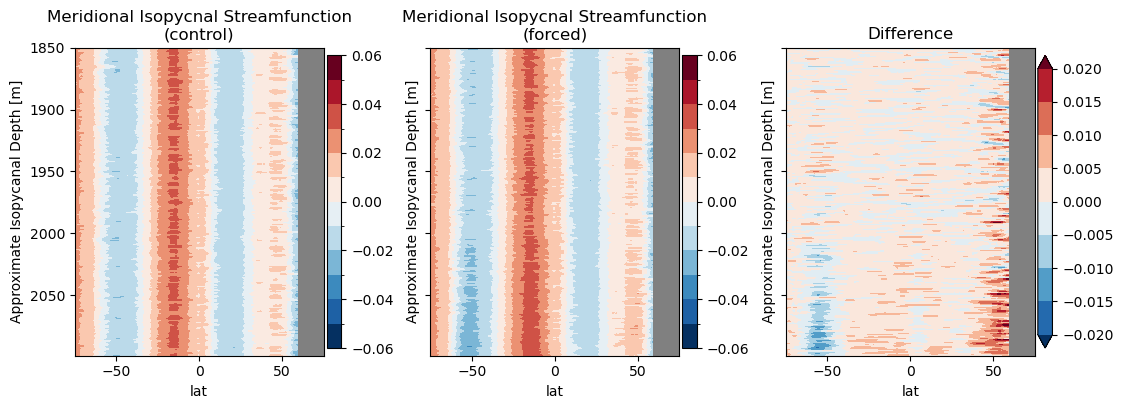

In [38]:
#define streamfunction levels
def plot_tauy(fig, ax, psi, levels = np.arange(-0.06, 0.06 + 0.01, 0.01)): 
    # levels = [-42, -38, -34, -30, -26, -22, -18, -14, -10, -6, -2, 0,   2,   6,  10,  14,  18,  22,  26,  30,  34,  38,  42]
    p1 = psi.plot.contourf(
        ax=ax, x="lat", y="year", levels=levels,
        add_colorbar=False, cmap='RdBu_r'
    )
    c1 = fig.colorbar(p1, ax=ax, pad=0.01, spacing='uniform',
                      extend='both', shrink=0.95, orientation='vertical')
    c1.ax.tick_params(labelsize=10)
    ax.set_facecolor('gray')
    ax.set_xlim(-75, 75)
    ax.invert_yaxis()
    ax.set_ylabel("Approximate Isopycanal Depth [m]")

# create one figure with two subplots
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

# first subplot: control
ax = axes[0]
exp = "control"
ds_avgs = ds_avg.sel(exp=exp).groupby("time.year").mean("time")

plot_tauy(fig, ax, ds_avgs["tauy"].fillna(0.0))
ax.set_title(f"Meridional Isopycnal Streamfunction\n(control)")

ax = axes[1]
exp = "forced"
ds_avgs = ds_avg.sel(exp=exp).groupby("time.year").mean("time")

plot_tauy(fig, ax, ds_avgs["tauy"].fillna(0.0))
ax.set_title(f"Meridional Isopycnal Streamfunction\n(forced)")

ax = axes[2]
levels = np.arange(-0.02, 0.02 + 0.001, 0.005)
diff = ds_avg.sel(exp="forced") - ds_avg.sel(exp="control")
ds_avgs = diff.groupby("time.year").mean("time")

plot_tauy(fig, ax, ds_avgs["tauy"].fillna(0.0), levels = levels)
ax.set_title(f"Difference")

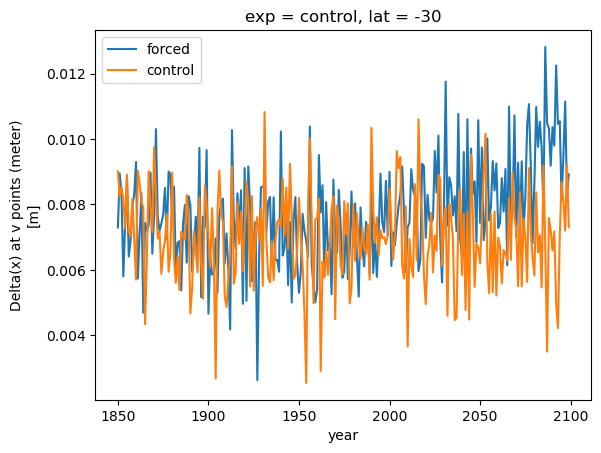

In [36]:
ds_yearly_avg = ds_avg.groupby("time.year").mean("time")
ds_yearly_avg["tauy"].sel(lat = -30, exp = "forced").plot(label = "forced")
ds_yearly_avg["tauy"].sel(lat = -30, exp = "control").plot(label = "control")
plt.legend()

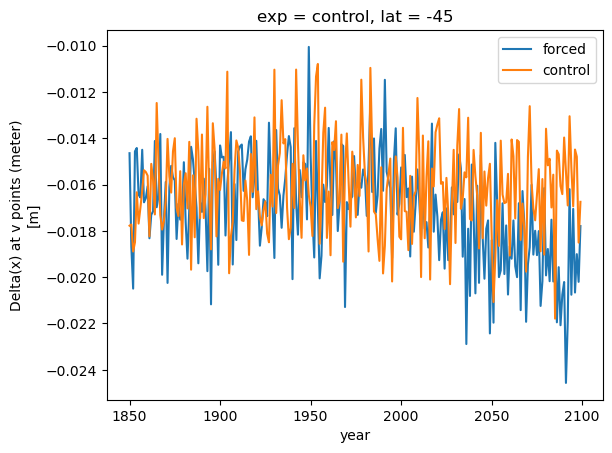

In [37]:
ds_yearly_avg = ds_avg.groupby("time.year").mean("time")
ds_yearly_avg["tauy"].sel(lat = -45, exp = "forced").plot(label = "forced")
ds_yearly_avg["tauy"].sel(lat = -45, exp = "control").plot(label = "control")
plt.legend()

In [9]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
psis_ds.to_zarr(savedir + "IndoPacIsopycnalOverturning.zarr", mode = "w")